<a href="https://colab.research.google.com/github/Anthony-Kabamba/maintenance-data-analysis/blob/main/260609_grinder_operational_readiness_analysis_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!find /content/drive -name "*.xlsx"

find: ‘/content/drive’: No such file or directory


In [2]:
import pandas as pd

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
df = pd.read_excel('/content/drive/MyDrive/Maintenance Data Analysis/DataSets/grinder_inspection_synthetic_dataset_01.xlsx')
df.head()

,date,time,shift,grinder_asset_id,grinder_specification,power_cable_ok,trigger_switch_ok,guard_ok,side_handle_ok,flange_locknut_ok,abrasive_disc_ok,rpm_compatible,housing_vents_ok,spindle_tightness_ok,ppe_confirmed,inspection_result,defects_noted,tagged_out
0,2025-06-02,06:30,Day,AG-01,4 inch,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Pass,NaN,No
1,2025-06-02,06:35,Day,AG-02,7 inch,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Pass,NaN,No
2,2025-06-02,06:40,Day,AG-03,4 inch,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Pass,NaN,No
3,2025-06-02,06:45,Day,AG-04,7 inch,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Fail,Guard missing,Yes
4,2025-06-02,06:50,Day,AG-05,4 inch,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Pass,NaN,No


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   date                   50 non-null     object
 1   time                   50 non-null     object
 2   shift                  50 non-null     object
 3   grinder_asset_id       50 non-null     object
 4   grinder_specification  50 non-null     object
 5   power_cable_ok         50 non-null     object
 6   trigger_switch_ok      50 non-null     object
 7   guard_ok               50 non-null     object
 8   side_handle_ok         50 non-null     object
 9   flange_locknut_ok      50 non-null     object
 10  abrasive_disc_ok       50 non-null     object
 11  rpm_compatible         50 non-null     object
 12  housing_vents_ok       50 non-null     object
 13  spindle_tightness_ok   50 non-null     object
 14  ppe_confirmed          50 non-null     object
 15  inspection_result      50

In [5]:
df.columns


Index(['date', 'time', 'shift', 'grinder_asset_id', 'grinder_specification',
       'power_cable_ok', 'trigger_switch_ok', 'guard_ok', 'side_handle_ok',
       'flange_locknut_ok', 'abrasive_disc_ok', 'rpm_compatible',
       'housing_vents_ok', 'spindle_tightness_ok', 'ppe_confirmed',
       'inspection_result', 'defects_noted', 'tagged_out'],
      dtype='object')

In [6]:
df.isnull().sum()

,0
date,0
time,0
shift,0
grinder_asset_id,0
grinder_specification,0
power_cable_ok,0
trigger_switch_ok,0
guard_ok,0
side_handle_ok,0
flange_locknut_ok,0


In [7]:
df[df["defects_noted"].isnull()]
df["defects_noted"].value_counts(dropna=False)

,count
defects_noted,
NaN,34
Side handle loose,2
Disc cracked near edge,2
Cable insulation damaged,2
Disc RPM rating below grinder max,2
Cooling vents blocked with dust,2
Cooling vents partially dusty,1
Guard missing,1
Flange worn,1


In [8]:
df["inspection_result"].value_counts()


,count
inspection_result,
Pass,37
Fail,13


In [9]:
round(
    df["inspection_result"].value_counts(normalize=True) * 100,
    2
)

,proportion
inspection_result,
Pass,74.0
Fail,26.0


In [10]:
df[
    (df["inspection_result"] == "Pass") &
    (df["tagged_out"] == "Yes")
]

,date,time,shift,grinder_asset_id,grinder_specification,power_cable_ok,trigger_switch_ok,guard_ok,side_handle_ok,flange_locknut_ok,abrasive_disc_ok,rpm_compatible,housing_vents_ok,spindle_tightness_ok,ppe_confirmed,inspection_result,defects_noted,tagged_out


In [15]:
inspection_columns = [
    "power_cable_ok",
    "trigger_switch_ok",
    "guard_ok",
    "side_handle_ok",
    "flange_locknut_ok",
    "abrasive_disc_ok",
    "rpm_compatible",
    "housing_vents_ok",
    "spindle_tightness_ok",
    "ppe_confirmed"
]


<Axes: >

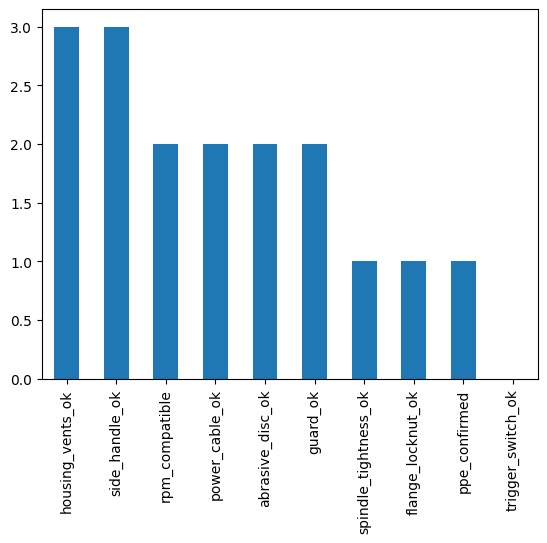

In [16]:
(df[inspection_columns] == "No").sum().sort_values(ascending=False).plot.bar()

In [17]:
pd.crosstab(
    df["grinder_asset_id"],
    df["inspection_result"]
)

inspection_result,Fail,Pass
grinder_asset_id,,
AG-01,0,12
AG-02,2,8
AG-03,4,5
AG-04,3,6
AG-05,4,6


In [18]:
grinder_summary = pd.crosstab(
    df["grinder_asset_id"],
    df["inspection_result"]
)

grinder_summary

inspection_result,Fail,Pass
grinder_asset_id,,
AG-01,0,12
AG-02,2,8
AG-03,4,5
AG-04,3,6
AG-05,4,6


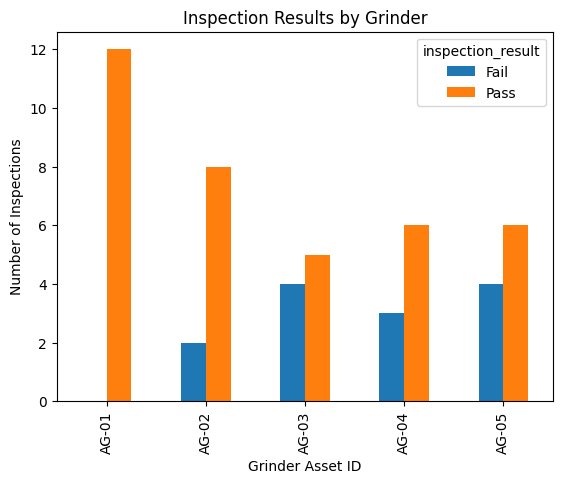

In [19]:
import matplotlib.pyplot as plt

grinder_summary.plot(kind="bar")

plt.title("Inspection Results by Grinder")
plt.xlabel("Grinder Asset ID")
plt.ylabel("Number of Inspections")
plt.show()

In [20]:
df[
    (df["grinder_asset_id"] == "AG-03") &
    (df["inspection_result"] == "Fail")
]

,date,time,shift,grinder_asset_id,grinder_specification,power_cable_ok,trigger_switch_ok,guard_ok,side_handle_ok,flange_locknut_ok,abrasive_disc_ok,rpm_compatible,housing_vents_ok,spindle_tightness_ok,ppe_confirmed,inspection_result,defects_noted,tagged_out
6,2025-06-02,14:15,Afternoon,AG-03,4 inch,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,Fail,Side handle loose,No
17,2025-06-04,06:40,Day,AG-03,4 inch,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Fail,Flange worn,No
31,2025-06-06,06:40,Day,AG-03,4 inch,Yes,Yes,No,No,Yes,Yes,Yes,Yes,Yes,Yes,Fail,Guard missing; side handle loose,Yes
37,2025-06-09,06:40,Day,AG-03,4 inch,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,Fail,Disc cracked near edge,Yes


In [21]:
df[
    (df["grinder_asset_id"] == "AG-05") &
    (df["inspection_result"] == "Fail")
]

,date,time,shift,grinder_asset_id,grinder_specification,power_cable_ok,trigger_switch_ok,guard_ok,side_handle_ok,flange_locknut_ok,abrasive_disc_ok,rpm_compatible,housing_vents_ok,spindle_tightness_ok,ppe_confirmed,inspection_result,defects_noted,tagged_out
12,2025-06-03,06:50,Day,AG-05,4 inch,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,Fail,Disc cracked near edge,Yes
26,2025-06-05,06:50,Day,AG-05,4 inch,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,No,Yes,Fail,Spindle loose during rotation test,Yes
39,2025-06-09,06:50,Day,AG-05,4 inch,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Fail,Cable insulation damaged,No
47,2025-06-10,14:10,Afternoon,AG-05,4 inch,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,Fail,Side handle loose,No


Initial Finding

1. Housing vent condition and side-handle condition were the most frequently observed inspection deficiencies, each recording three failures.

2. AG-01 demonstrated the strongest operational readiness performance, recording twelve successful inspections and no failures.

3. AG-03 and AG-05 exhibited the highest observed failure rates and should be prioritized for further inspection and defect review.

In [22]:
df["tagged_out"].value_counts()

,count
tagged_out,
No,43
Yes,7


In [23]:
round(
    df["tagged_out"].value_counts(normalize=True) * 100,
    2
)

,proportion
tagged_out,
No,86.0
Yes,14.0


1. 7 inspections resulted in tag-out which is 14% of total observations.
